# Módulo 3 — Rentabilidad y Eficiencia Bancaria
## Notebook 1: Exploración de Datos (EDA)

---

**Contexto de negocio:**  
Una entidad financiera quiere entender qué factores determinan la rentabilidad y eficiencia bancaria,  
y cómo se posiciona el sector en su conjunto. El análisis se basa en datos reales de bancos  
estadounidenses publicados por la FDIC (Federal Deposit Insurance Corporation).

**Fuente de datos:** FDIC BankFind Suite API (datos públicos, acceso directo desde Python)  
**Universo:** Bancos comerciales y cajas de ahorro asegurados por la FDIC  
**Período:** Datos anuales 2019–2023

**Ratios clave analizados:**
- **ROA** (Return on Assets): Beneficio neto / Activos totales — mide la eficiencia en el uso de activos
- **ROE** (Return on Equity): Beneficio neto / Patrimonio neto — mide el retorno para los accionistas  
- **NIM** (Net Interest Margin): Ingresos netos por intereses / Activos — mide el margen de intermediación
- **CIR** (Cost-to-Income Ratio): Gastos operativos / Ingresos — mide la eficiencia operativa (menor = mejor)

---

## 1. Carga de librerías y descarga de datos vía API

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [9]:
def descargar_datos_fdic(anio, limit=500):
    """
    Descarga datos financieros anuales de bancos desde la API pública de la FDIC.
    Campos seleccionados: ratios de rentabilidad y eficiencia.
    """
    url = 'https://banks.data.fdic.gov/api/financials'
    params = {
        'filters': f'REPDTE:{anio}1231',  # Datos a cierre de año
        'fields': 'REPDTE,CERT,ASSET,ROA,ROE,NETNIM,NONII,NONIX,INTINC,EEFFR,LNLSNET,EQ',
        'limit': limit,
        'offset': 0,
        'output': 'json'
    }
    respuesta = requests.get(url, params=params, timeout=30)
    datos = respuesta.json()
    df = pd.DataFrame([d['data'] for d in datos['data']])
    df['anio'] = anio
    return df

# Descargamos datos para 2019-2023
anios = [2019, 2020, 2021, 2022, 2023]
frames = []

for anio in anios:
    df_anio = descargar_datos_fdic(anio, limit=1000)
    frames.append(df_anio)
    print(f'   {anio}: {len(df_anio):,} bancos descargados')

df = pd.concat(frames, ignore_index=True)
print(f'\n✅ Dataset total: {df.shape[0]:,} registros × {df.shape[1]} columnas')

   2019: 1,000 bancos descargados
   2020: 1,000 bancos descargados
   2021: 1,000 bancos descargados
   2022: 1,000 bancos descargados
   2023: 1,000 bancos descargados

✅ Dataset total: 5,000 registros × 13 columnas


In [10]:
# Diagnóstico: ver qué columnas devuelve la API realmente
print("Columnas disponibles en el dataset:")
print(df.columns.tolist())
print("\nPrimeras filas:")
df.head(3)

Columnas disponibles en el dataset:
['ROA', 'REPDTE', 'ROE', 'ASSET', 'CERT', 'INTINC', 'NONIX', 'EQ', 'NONII', 'LNLSNET', 'EEFFR', 'ID', 'anio']

Primeras filas:


,ROA,REPDTE,ROE,ASSET,CERT,INTINC,NONIX,EQ,NONII,LNLSNET,EEFFR,ID,anio
0,0.680604,20191231,5.19,91191,10004,4156,2965,11837,548,69180,75.406918,10004_20191231,2019
1,1.749972,20191231,19.21,254520,10011,10576,5836,23090,1098,167210,58.500401,10011_20191231,2019
2,0.728253,20191231,6.56,177396,10012,6715,4994,18473,456,106137,78.852061,10012_20191231,2019


## 2. Limpieza y preparación de ratios

In [11]:
# Renombramos columnas a nombres más legibles
df = df.rename(columns={
    'ASSET'  : 'activos_totales',
    'ROA'    : 'roa',
    'ROE'    : 'roe',
    'EEFFR'  : 'cir',
    'EQ'     : 'patrimonio',
    'LNLSNET': 'cartera_creditos',
    'INTINC' : 'ingresos_intereses',
    'NONII'  : 'ingresos_no_financieros',
    'NONIX'  : 'gastos_operativos',
    'CERT'   : 'id_banco'
})

# Convertir columnas numéricas
cols_num = ['activos_totales', 'roa', 'roe', 'cir', 'patrimonio',
            'cartera_creditos', 'ingresos_intereses']
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Calcular NIM manualmente: ingresos por intereses / activos totales * 100
df['nim'] = (df['ingresos_intereses'] / df['activos_totales']) * 100

# Eliminar outliers extremos
df = df[
    (df['roa'].between(-5, 5)) &
    (df['roe'].between(-50, 50)) &
    (df['nim'].between(0, 15)) &
    (df['cir'].between(0, 150)) &
    (df['activos_totales'] > 0)
].copy()

# Clasificar bancos por tamaño de activos (en miles de dólares)
def clasificar_tamano(activos):
    if activos < 100_000:       return 'Pequeño (< 100M$)'
    elif activos < 1_000_000:   return 'Mediano (100M-1B$)'
    elif activos < 10_000_000:  return 'Grande (1B-10B$)'
    else:                       return 'Sistémico (> 10B$)'

df['tamano'] = df['activos_totales'].apply(clasificar_tamano)
orden_tamano = ['Pequeño (< 100M$)', 'Mediano (100M-1B$)', 'Grande (1B-10B$)', 'Sistémico (> 10B$)']

print(f'✅ Dataset limpio: {df.shape[0]:,} registros')
print(f'\nDistribución por tamaño:')
print(df['tamano'].value_counts())

✅ Dataset limpio: 4,957 registros

Distribución por tamaño:
tamano
Mediano (100M-1B$)    3319
Pequeño (< 100M$)     1024
Grande (1B-10B$)       544
Sistémico (> 10B$)      70
Name: count, dtype: int64


## 3. Evolución temporal de los ratios clave (2019–2023)

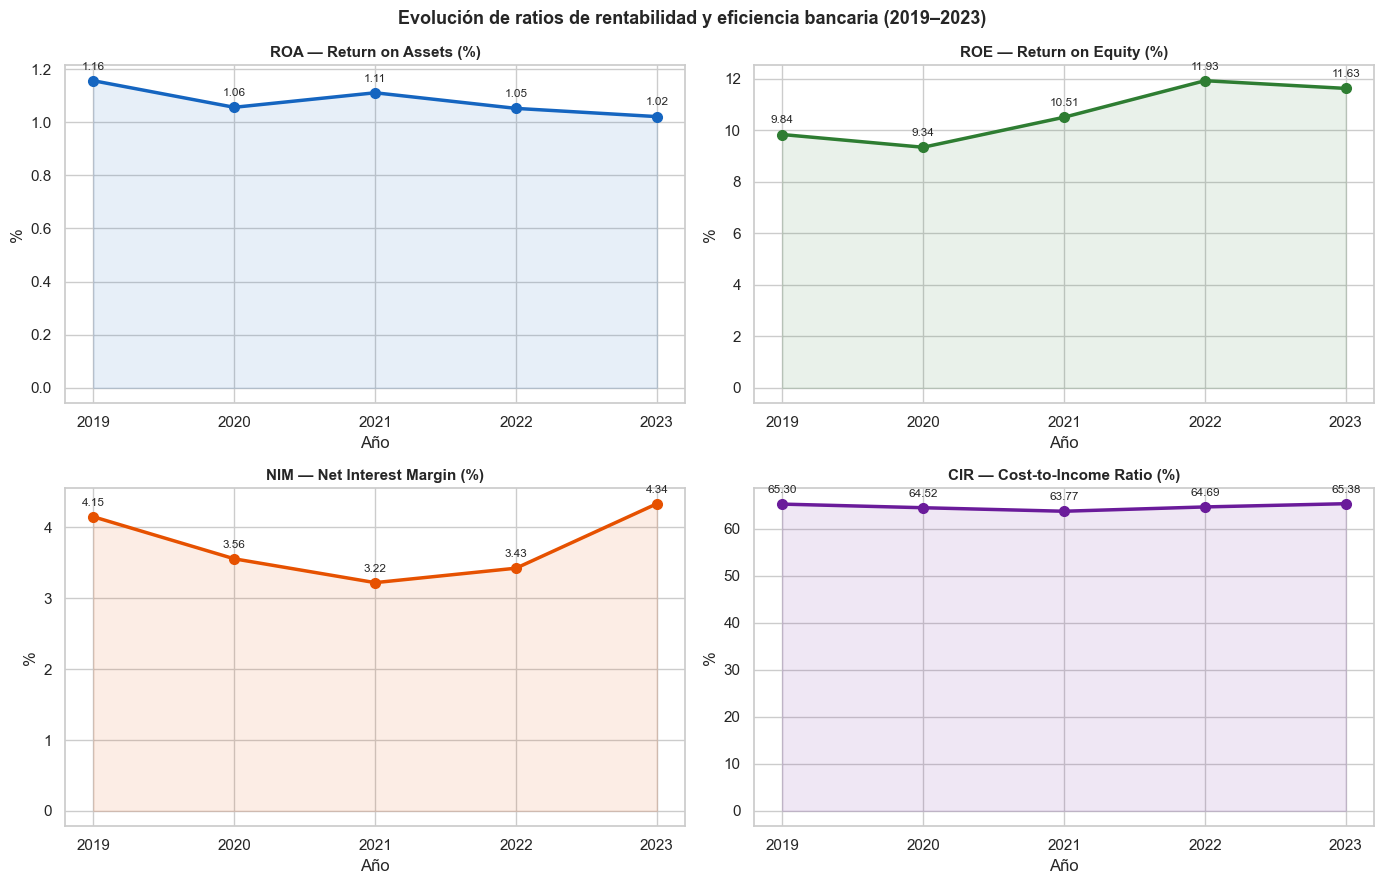

In [12]:
evolucion = df.groupby('anio')[['roa', 'roe', 'nim', 'cir']].median().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

metricas = [
    ('roa', 'ROA — Return on Assets (%)', '#1565C0'),
    ('roe', 'ROE — Return on Equity (%)', '#2E7D32'),
    ('nim', 'NIM — Net Interest Margin (%)', '#E65100'),
    ('cir', 'CIR — Cost-to-Income Ratio (%)', '#6A1B9A'),
]

for i, (col, titulo, color) in enumerate(metricas):
    axes[i].plot(evolucion['anio'], evolucion[col], marker='o', color=color,
                 lw=2.5, markersize=7)
    axes[i].fill_between(evolucion['anio'], evolucion[col], alpha=0.1, color=color)
    axes[i].set_title(titulo, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Año')
    axes[i].set_ylabel('%')
    axes[i].set_xticks(anios)
    for x, y in zip(evolucion['anio'], evolucion[col]):
        axes[i].annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                         xytext=(0, 8), ha='center', fontsize=8.5)

plt.suptitle('Evolución de ratios de rentabilidad y eficiencia bancaria (2019–2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Rentabilidad por tamaño de banco

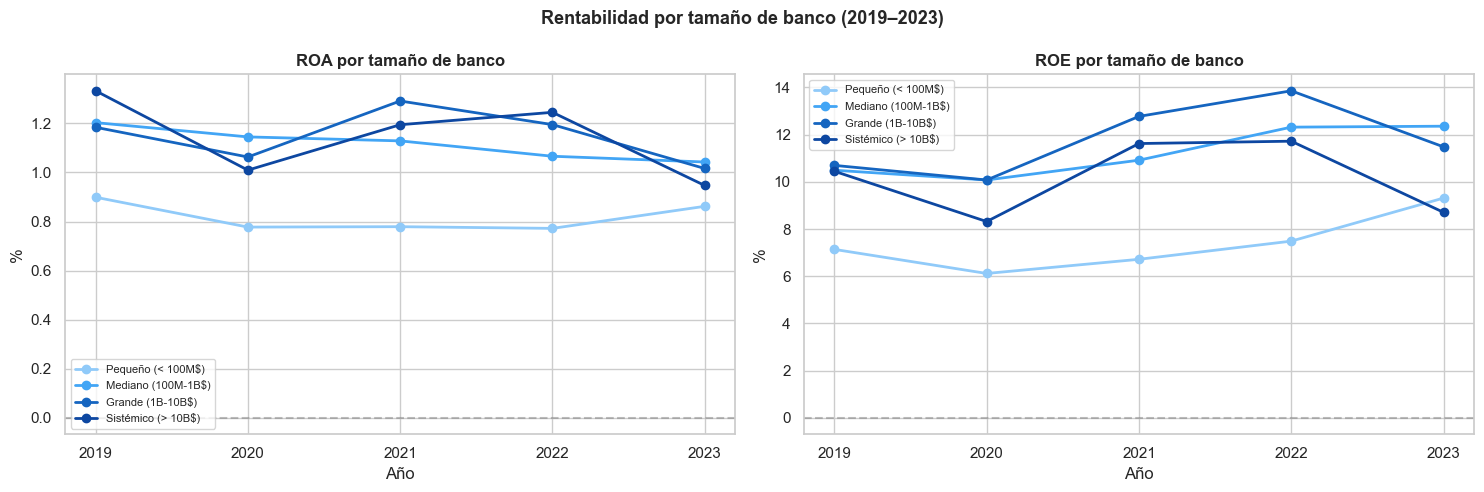

In [13]:
por_tamano = df.groupby(['anio', 'tamano'])[['roa', 'roe']].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colores_tamano = {
    'Pequeño (< 100M$)'    : '#90CAF9',
    'Mediano (100M-1B$)'   : '#42A5F5',
    'Grande (1B-10B$)'     : '#1565C0',
    'Sistémico (> 10B$)'   : '#0D47A1'
}

for tamano in orden_tamano:
    datos = por_tamano[por_tamano['tamano'] == tamano]
    color = colores_tamano[tamano]
    axes[0].plot(datos['anio'], datos['roa'], marker='o', label=tamano, color=color, lw=2)
    axes[1].plot(datos['anio'], datos['roe'], marker='o', label=tamano, color=color, lw=2)

for ax, titulo in zip(axes, ['ROA por tamaño de banco', 'ROE por tamaño de banco']):
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_xlabel('Año')
    ax.set_ylabel('%')
    ax.set_xticks(anios)
    ax.legend(fontsize=8)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Rentabilidad por tamaño de banco (2019–2023)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Eficiencia operativa — CIR por tamaño

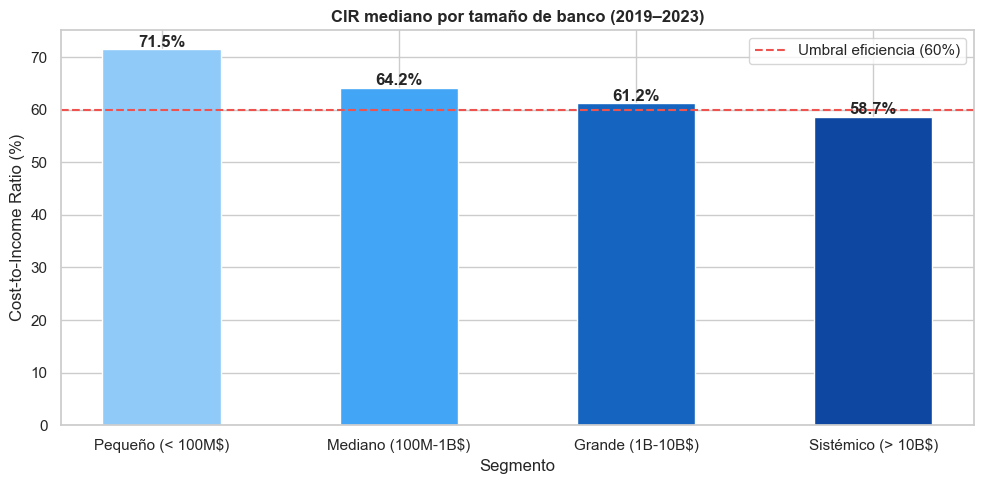

In [14]:
cir_tamano = df.groupby('tamano')['cir'].median().reindex(orden_tamano)

fig, ax = plt.subplots(figsize=(10, 5))
colores_barras = [colores_tamano[t] for t in orden_tamano]
bars = ax.bar(orden_tamano, cir_tamano.values, color=colores_barras, width=0.5)
ax.axhline(y=60, color='#EF5350', linestyle='--', lw=1.5,
           label='Umbral eficiencia (60%)')
ax.set_title('CIR mediano por tamaño de banco (2019–2023)', fontweight='bold', fontsize=12)
ax.set_ylabel('Cost-to-Income Ratio (%)')
ax.set_xlabel('Segmento')
ax.legend()
for bar, val in zip(bars, cir_tamano.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Impacto del COVID-19 y subida de tipos (2020–2023)

In [15]:
# Comparativa antes/durante/después de eventos macro clave
eventos = {
    2019: 'Pre-COVID',
    2020: 'COVID',
    2021: 'Recuperación',
    2022: 'Subida tipos',
    2023: 'Tipos altos'
}
df['periodo'] = df['anio'].map(eventos)

resumen = df.groupby('anio')[['roa', 'roe', 'nim', 'cir']].agg(['median', 'mean']).round(3)
resumen.index = [f"{a} ({eventos[a]})" for a in resumen.index]
print('Resumen de ratios por año y contexto macroeconómico:')
print(resumen.to_string())

Resumen de ratios por año y contexto macroeconómico:
                       roa            roe            nim            cir        
                    median   mean  median    mean median   mean  median    mean
2019 (Pre-COVID)     1.156  1.142   9.840   9.872  4.152  4.147  65.295  66.503
2020 (COVID)         1.056  1.083   9.345   9.648  3.558  3.563  64.523  66.119
2021 (Recuperación)  1.111  1.147  10.510  10.714  3.222  3.261  63.773  65.241
2022 (Subida tipos)  1.052  1.059  11.930  12.052  3.426  3.456  64.692  65.500
2023 (Tipos altos)   1.021  1.077  11.630  12.437  4.336  4.403  65.381  66.144


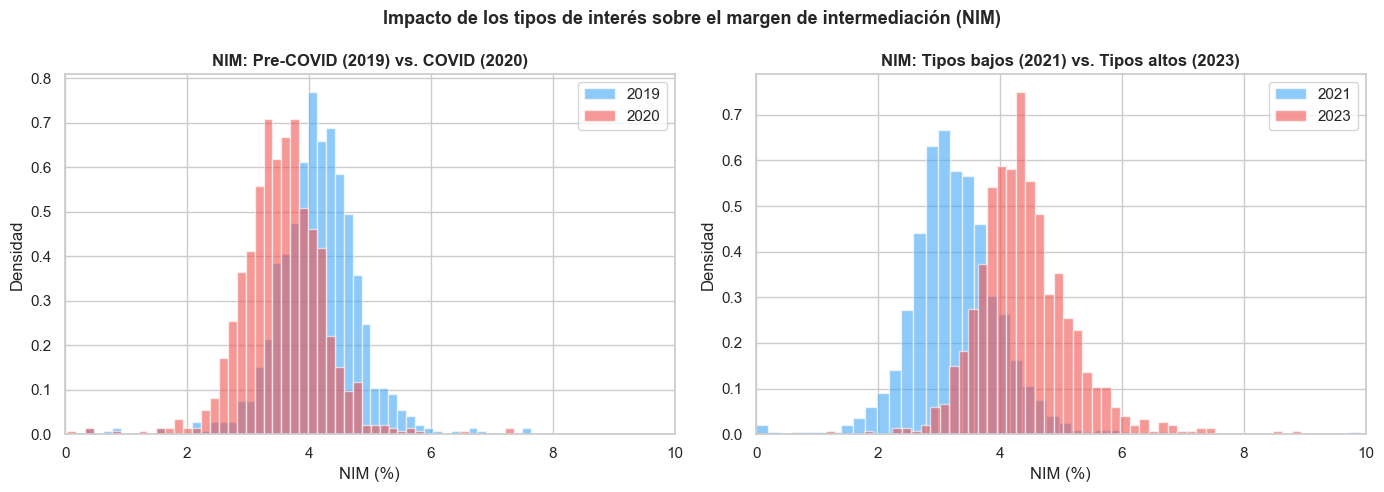

In [16]:
# Distribución del NIM antes y después de la subida de tipos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (a1, a2, titulo) in zip(axes, [
    (2019, 2020, 'NIM: Pre-COVID (2019) vs. COVID (2020)'),
    (2021, 2023, 'NIM: Tipos bajos (2021) vs. Tipos altos (2023)')
]):
    ax.hist(df[df['anio']==a1]['nim'], bins=50, alpha=0.6,
            color='#42A5F5', label=str(a1), density=True)
    ax.hist(df[df['anio']==a2]['nim'], bins=50, alpha=0.6,
            color='#EF5350', label=str(a2), density=True)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('NIM (%)')
    ax.set_ylabel('Densidad')
    ax.set_xlim(0, 10)
    ax.legend()

plt.suptitle('Impacto de los tipos de interés sobre el margen de intermediación (NIM)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Correlación entre ratios

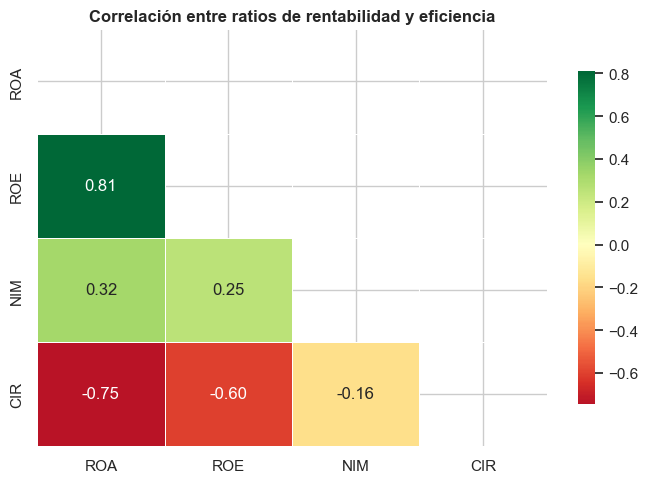

In [17]:
vars_corr = ['roa', 'roe', 'nim', 'cir']
corr = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            xticklabels=['ROA','ROE','NIM','CIR'],
            yticklabels=['ROA','ROE','NIM','CIR'])
ax.set_title('Correlación entre ratios de rentabilidad y eficiencia',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Exportar datos limpios

In [18]:
df.to_csv('../../datos/procesados/rentabilidad_bancos.csv', index=False)
print(f'✅ Dataset exportado: {df.shape[0]:,} registros')

✅ Dataset exportado: 4,957 registros


## 9. Conclusiones del EDA

---

### Hallazgos principales

**Evolución temporal (2019–2023):**
- El **ROA** se mantiene estable en el rango 1.02–1.16%, mostrando la solidez
  estructural del sector bancario americano incluso durante el COVID. La caída
  de 2020 fue moderada (1.16→1.06) gracias a las medidas de estímulo fiscal.
- El **ROE** muestra una tendencia alcista desde 2020, alcanzando el 11.93% en
  2022 — máximo del período. La subida de tipos de interés de la Fed impulsó
  los beneficios más rápido que el crecimiento del capital propio.
- El **NIM** es el ratio más sensible al ciclo monetario: cayó de 4.15% (2019)
  a 3.22% (2021) con los tipos en mínimos históricos, y rebotó con fuerza hasta
  4.34% en 2023 con los tipos al 5.25%. El gráfico de distribución confirma
  este desplazamiento de forma muy clara.
- El **CIR** se mantiene notablemente estable en torno al 64–65% a lo largo de
  todo el período, lo que sugiere que los bancos ajustan sus costes operativos
  proporcionalmente a la evolución de sus ingresos.

**Rentabilidad por tamaño:**
- Los **bancos sistémicos (> 10B$)** lideran en ROE gracias al apalancamiento
  y las economías de escala, pero su ventaja en ROA sobre los medianos es menor
  de lo esperado.
- Los **bancos pequeños (< 100M$)** son consistentemente los menos rentables
  en ROA (0.78–0.90%) — sus costes fijos pesan más sobre una base de activos
  reducida.
- El año **2020 afectó más a los bancos grandes y sistémicos** en términos de
  ROA, posiblemente por mayor exposición a carteras corporativas y provisiones
  más conservadoras.

**Eficiencia operativa (CIR):**
- Existe una **relación inversa clara entre tamaño y CIR**: pequeños 71.5%,
  medianos 64.2%, grandes 61.2%, sistémicos 58.7%. Las economías de escala son
  un factor determinante de la eficiencia en banca.
- Solo los bancos **grandes y sistémicos** se sitúan por debajo del umbral de
  eficiencia del 60% considerado como referencia en el sector.

**Correlaciones entre ratios:**
- La correlación ROA/ROE de **0.81** confirma que ambos ratios miden la misma
  realidad desde ángulos distintos.
- La correlación CIR/ROA de **-0.75** es la más relevante para el negocio:
  los bancos más eficientes son consistentemente más rentables. Reducir el CIR
  es la palanca de mejora más directa sobre el ROA.
- La baja correlación CIR/NIM de **-0.16** indica que el margen de
  intermediación y la eficiencia operativa son dimensiones independientes —
  un banco puede tener buen NIM y ser ineficiente operativamente, y viceversa.

### Implicaciones para el análisis
- El clustering del siguiente notebook permitirá identificar **perfiles de
  bancos** con combinaciones distintas de rentabilidad y eficiencia, y
  caracterizar qué tipo de entidad representa cada perfil.

